In [1]:

# MOVIE RATING PREDICTION #

#IMPORT REQUIRED LIBRARIES
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, r2_score

In [2]:
#LOAD THE DATASET
df = pd.read_csv('/content/IMDb Movies India.csv', encoding='latin1')
df.info()
df.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15509 entries, 0 to 15508
Data columns (total 10 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   Name      15509 non-null  object 
 1   Year      14981 non-null  object 
 2   Duration  7240 non-null   object 
 3   Genre     13632 non-null  object 
 4   Rating    7919 non-null   float64
 5   Votes     7920 non-null   object 
 6   Director  14984 non-null  object 
 7   Actor 1   13892 non-null  object 
 8   Actor 2   13125 non-null  object 
 9   Actor 3   12365 non-null  object 
dtypes: float64(1), object(9)
memory usage: 1.2+ MB


,Name,Year,Duration,Genre,Rating,Votes,Director,Actor 1,Actor 2,Actor 3
0,,NaN,NaN,Drama,NaN,NaN,J.S. Randhawa,Manmauji,Birbal,Rajendra Bhatia
1,#Gadhvi (He thought he was Gandhi),(2019),109 min,Drama,7.0,8,Gaurav Bakshi,Rasika Dugal,Vivek Ghamande,Arvind Jangid
2,#Homecoming,(2021),90 min,"Drama, Musical",NaN,NaN,Soumyajit Majumdar,Sayani Gupta,Plabita Borthakur,Roy Angana
3,#Yaaram,(2019),110 min,"Comedy, Romance",4.4,35,Ovais Khan,Prateik,Ishita Raj,Siddhant Kapoor
4,...And Once Again,(2010),105 min,Drama,NaN,NaN,Amol Palekar,Rajat Kapoor,Rituparna Sengupta,Antara Mali


In [3]:
# Clean 'Votes' column
df['Votes'] = df['Votes'].str.replace(',', '').str.replace('$', '').str.replace('M', '').astype(float)

# Clean 'Duration' column
df['Duration'] = df['Duration'].str.replace(' min', '').astype(float)

print(df.head())
print(df.info())

                                 Name    Year  Duration            Genre  \
0                                         NaN       NaN            Drama   
1  #Gadhvi (He thought he was Gandhi)  (2019)     109.0            Drama   
2                         #Homecoming  (2021)      90.0   Drama, Musical   
3                             #Yaaram  (2019)     110.0  Comedy, Romance   
4                   ...And Once Again  (2010)     105.0            Drama   

   Rating  Votes            Director       Actor 1             Actor 2  \
0     NaN    NaN       J.S. Randhawa      Manmauji              Birbal   
1     7.0    8.0       Gaurav Bakshi  Rasika Dugal      Vivek Ghamande   
2     NaN    NaN  Soumyajit Majumdar  Sayani Gupta   Plabita Borthakur   
3     4.4   35.0          Ovais Khan       Prateik          Ishita Raj   
4     NaN    NaN        Amol Palekar  Rajat Kapoor  Rituparna Sengupta   

           Actor 3  
0  Rajendra Bhatia  
1    Arvind Jangid  
2       Roy Angana  
3  Siddhant Ka

In [4]:
# Select useful columns
df = df[['Votes','Duration','Rating']]
df.dropna(inplace=True)

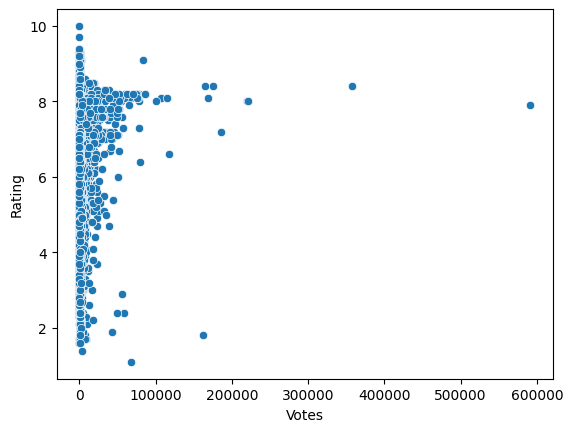

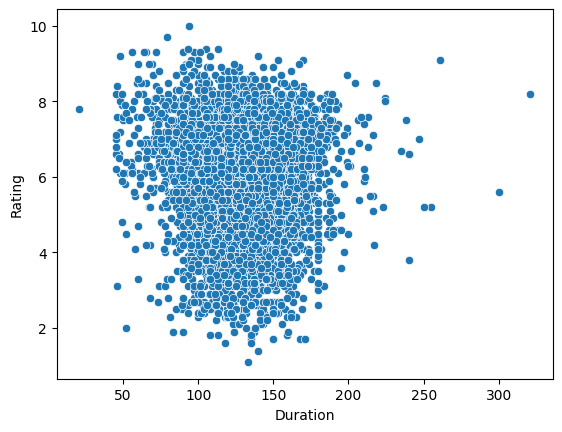

In [5]:
# EDA(exploratory data analysis)
sns.scatterplot(x='Votes',y='Rating',data=df)
plt.show()

sns.scatterplot(x='Duration',y='Rating',data=df)
plt.show()

In [6]:
# SPLITING TRAINING AND TESTING DATASETS
X = df[['Votes','Duration']]
y = df['Rating']

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

X_train,X_test,y_train,y_test = train_test_split(X_scaled,y,test_size=0.2)

In [7]:
# Model
model = LinearRegression()
model.fit(X_train,y_train)

LinearRegression()

In [8]:
#PREDICTION
pred = model.predict(X_test)

In [9]:
#MODEL EVALUATION
print("MAE:", mean_absolute_error(y_test,pred))
print("R2 Score:", r2_score(y_test,pred))

MAE: 1.1132630958729983
R2 Score: -0.008302392138781034
